# Bank Marketing Dataset — Data Cleaning & Validation
---
**Mục tiêu:** Làm sạch, chuẩn hóa và xác thực bộ dữ liệu marketing ngân hàng trước khi đưa vào phân tích hoặc mô hình hóa.

**Pipeline tổng thể:**
1. Import thư viện & Đọc dữ liệu
2. Khám phá dữ liệu ban đầu (EDA sơ bộ)
3. Làm sạch & Chuẩn hóa văn bản
4. Phát hiện giá trị không hợp lệ
5. Data Transformation (Logic-based imputation)
6. Xử lý ngoại lai (Outlier Treatment)
7. Ép kiểu dữ liệu (Type Casting)
8. Xác thực sau làm sạch (Rule-based Validation)
9. So sánh trước/sau & Xuất kết quả
10. Hàm làm sạch tái sử dụng (Reusable Pipeline)

## **1. Import Thư Viện & Đọc Dữ Liệu**
Nạp các thư viện cần thiết và đọc dữ liệu thô từ file CSV.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu từ file CSV
df_raw = pd.read_csv('bank_data.csv')

## **2. Khám Phá Dữ Liệu Ban Đầu (Initial EDA)**
Kiểm tra cấu trúc tổng thể: kích thước, kiểu dữ liệu, giá trị thiếu và thống kê mô tả.

In [19]:
# 2. Cấu trúc tổng thể
print("Shape:", df_raw.shape)
print("\nColumn names:")
print(df_raw.columns.tolist())
print("\nData types:")
print(df_raw.dtypes)

Shape: (11162, 17)

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']

Data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object


In [20]:
# 10 dòng đầu tiên
df_raw.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
5,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
6,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
7,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
8,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes
9,28,services,single,secondary,no,5090,yes,no,unknown,6,may,1297,3,-1,0,unknown,yes


In [21]:
# Rà soát dữ liệu bị thiếu
print("Missing values per column:")
df_raw.isna().sum()

Missing values per column:


,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [22]:
# Thống kê mô tả tổng quát
display(df_raw.describe(include="all"))

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
count,11162.000000,11162,11162,11162,11162,11162.000000,11162,11162,11162,11162.000000,11162,11162.000000,11162.000000,11162.000000,11162.000000,11162,11162
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,management,married,secondary,no,NaN,no,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,2566,6351,5476,10994,NaN,5881,9702,8042,NaN,2824,NaN,NaN,NaN,NaN,8326,5873
mean,41.231948,NaN,NaN,NaN,NaN,1528.538524,NaN,NaN,NaN,15.658036,NaN,371.993818,2.508421,51.330407,0.832557,NaN,NaN
std,11.913369,NaN,NaN,NaN,NaN,3225.413326,NaN,NaN,NaN,8.420740,NaN,347.128386,2.722077,108.758282,2.292007,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,NaN,1.000000,NaN,2.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,32.000000,NaN,NaN,NaN,NaN,122.000000,NaN,NaN,NaN,8.000000,NaN,138.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,550.000000,NaN,NaN,NaN,15.000000,NaN,255.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,49.000000,NaN,NaN,NaN,NaN,1708.000000,NaN,NaN,NaN,22.000000,NaN,496.000000,3.000000,20.750000,1.000000,NaN,NaN


## **3. Làm Sạch & Chuẩn Hóa Văn Bản (Text Cleaning & Standardization)**
Tạo bản sao để làm việc, sau đó xử lý khoảng trắng, chuẩn hóa chữ hoa/thường và sửa lỗi chính tả.

In [23]:
# Tạo bản sao để làm việc, giữ nguyên df_raw
df = df_raw.copy()
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [24]:
# Kiểm tra và xóa dòng trùng lặp nếu có
duplicate_count = df.duplicated().sum()
print(f"Số dòng trùng lặp: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Đã loại bỏ các dòng trùng lặp.")

Số dòng trùng lặp: 0


In [25]:
# Xóa khoảng trắng ở đầu và cuối cho tất cả cột văn bản
text_columns = df.select_dtypes(include=['object']).columns
for col in text_columns:
    df.loc[:, col] = df[col].astype(str).str.strip()

df[text_columns]

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
0,admin.,married,secondary,no,yes,no,unknown,may,unknown,yes
1,admin.,married,secondary,no,no,no,unknown,may,unknown,yes
2,technician,married,secondary,no,yes,no,unknown,may,unknown,yes
3,services,married,secondary,no,yes,no,unknown,may,unknown,yes
4,admin.,married,tertiary,no,no,no,unknown,may,unknown,yes
...,...,...,...,...,...,...,...,...,...,...
11157,blue-collar,single,primary,no,yes,no,cellular,apr,unknown,no
11158,services,married,secondary,no,no,no,unknown,jun,unknown,no
11159,technician,single,secondary,no,no,no,cellular,aug,unknown,no
11160,technician,married,secondary,no,no,yes,cellular,may,failure,no


In [26]:
# Chuẩn hoá định dạng chữ (Title Case)
text_columns = df.select_dtypes(include=['object']).columns
for col in text_columns:
    df[col] = df[col].str.title()

df[text_columns]

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
0,Admin.,Married,Secondary,No,Yes,No,Unknown,May,Unknown,Yes
1,Admin.,Married,Secondary,No,No,No,Unknown,May,Unknown,Yes
2,Technician,Married,Secondary,No,Yes,No,Unknown,May,Unknown,Yes
3,Services,Married,Secondary,No,Yes,No,Unknown,May,Unknown,Yes
4,Admin.,Married,Tertiary,No,No,No,Unknown,May,Unknown,Yes
...,...,...,...,...,...,...,...,...,...,...
11157,Blue-Collar,Single,Primary,No,Yes,No,Cellular,Apr,Unknown,No
11158,Services,Married,Secondary,No,No,No,Unknown,Jun,Unknown,No
11159,Technician,Single,Secondary,No,No,No,Cellular,Aug,Unknown,No
11160,Technician,Married,Secondary,No,No,Yes,Cellular,May,Failure,No


In [27]:
# Sửa lỗi chính tả đã biết
df['job'] = df['job'].replace({'Admin.': 'Admin'})

## **4. Phát Hiện Giá Trị Không Hợp Lệ (Invalid Value Detection)**
Kiểm tra các ràng buộc nghiệp vụ: khoảng tuổi, thời lượng cuộc gọi, số lần liên hệ, và sự nhất quán giữa các cột.

In [28]:
# Kiểm tra các giá trị vi phạm quy tắc nghiệp vụ
invalid_rules = {
    "Tuổi ngoài khoảng (18-100)": df[(df['age'] < 18) | (df['age'] > 100)].shape[0],
    "Thời lượng cuộc gọi <= 0": df[df['duration'] <= 0].shape[0],
    "Số lần liên hệ (campaign) < 1": df[df['campaign'] < 1].shape[0],
    "Số ngày liên lạc trước đó (pdays) < -1": df[df['pdays'] < -1].shape[0]
}

print("-KIỂM TRA GIÁ TRỊ KHÔNG HỢP LỆ-")
for rule, count in invalid_rules.items():
    print(f"{rule}: {count} trường hợp")

-KIỂM TRA GIÁ TRỊ KHÔNG HỢP LỆ-
Tuổi ngoài khoảng (18-100): 0 trường hợp
Thời lượng cuộc gọi <= 0: 0 trường hợp
Số lần liên hệ (campaign) < 1: 0 trường hợp
Số ngày liên lạc trước đó (pdays) < -1: 0 trường hợp


In [29]:
# Kiểm tra tính nhất quán giữa poutcome và pdays
# Logic: nếu poutcome = 'unknown' thì khách chưa từng liên lạc → pdays phải = -1
abnormal_cases = df[(df['poutcome'] == 'Unknown') & (df['pdays'] != -1)]

print(f"Số lượng trường hợp 'unknown' nhưng đã từng liên lạc (pdays != -1): {len(abnormal_cases)}")

if len(abnormal_cases) > 0:
    print("Ví dụ các trường hợp bất thường:")
    print(abnormal_cases[['poutcome', 'pdays', 'previous']].head())
else:
    print("Xác nhận: 100% các dòng 'unknown' đều có pdays = -1.")

Số lượng trường hợp 'unknown' nhưng đã từng liên lạc (pdays != -1): 2
Ví dụ các trường hợp bất thường:
     poutcome  pdays  previous
2848  Unknown    188         2
5220  Unknown     98         1


## **5. Data Transformation (Logic-Based Imputation)**
Điền các giá trị thiếu/không rõ dựa trên logic nghiệp vụ, chuyển đổi biến mục tiêu và chuẩn hóa nhãn.

In [30]:
# Tạo df_cleaned từ df đã qua bước làm sạch văn bản
df_cleaned = df.copy()

# 1. Chuẩn hóa poutcome: 'Unknown' → 'New Customer'
# Logic: 'unknown' đi kèm pdays = -1 nghĩa là chưa từng liên lạc trước đây
df_cleaned['poutcome'] = df_cleaned['poutcome'].replace('Unknown', 'New_customer')

# 2. Chuyển đổi biến mục tiêu 'deposit' sang dạng số (0/1)
df_cleaned['deposit'] = df_cleaned['deposit'].map({'Yes': 1, 'No': 0})

# 3. Điền Job dựa trên Age
# Logic: khách hàng trên 60 tuổi chưa rõ nghề nghiệp thường đã nghỉ hưu
df_cleaned.loc[(df_cleaned['age'] > 60) & (df_cleaned['job'] == 'Unknown'), 'job'] = 'Retired'

# 4. Điền Education dựa trên Job
# Logic: một số nghề nghiệp có đặc thù về trình độ học vấn
df_cleaned.loc[(df_cleaned['education'] == 'Unknown') & (df_cleaned['job'] == 'Management'), 'education'] = 'Tertiary'
df_cleaned.loc[(df_cleaned['education'] == 'Unknown') & (df_cleaned['job'] == 'Services'), 'education'] = 'Secondary'

# 5. Điền Job dựa trên Education
# Logic: học vấn Primary thường gắn với nhóm Blue-collar
df_cleaned.loc[(df_cleaned['job'] == 'Unknown') & (df_cleaned['education'] == 'Primary'), 'job'] = 'Blue-Collar'

# 6. Xử lý các giá trị 'Unknown' còn sót lại bằng Mode
for col in ['job', 'education', 'contact']:
    if 'Unknown' in df_cleaned[col].values:
        mode_val = df_cleaned[col].mode()[0]
        df_cleaned[col] = df_cleaned[col].replace('Unknown', mode_val)

print("--- Hoàn tất bước Data Transformation ---")

--- Hoàn tất bước Data Transformation ---


## **6. Xử Lý Ngoại Lai (Outlier Treatment — IQR Capping)**
Áp dụng phương pháp IQR Capping để gọt bớt các giá trị cực đoan mà không loại bỏ dòng dữ liệu.

In [31]:
# Hàm xử lý ngoại lai bằng phương pháp IQR Capping
def handle_outliers_iqr(df, column):
    df[column] = pd.to_numeric(df[column], errors='coerce')

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping: thay thế các giá trị ngoài khoảng bằng ngưỡng min/max
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Áp dụng cho các cột số có khả năng chứa ngoại lai
cols_to_fix = ['balance', 'duration', 'campaign']
for col in cols_to_fix:
    if col in df_cleaned.columns:
        df_cleaned = handle_outliers_iqr(df_cleaned, col)

In [32]:
# So sánh giá trị Max trước và sau khi xử lý
print("Giá trị lớn nhất TRƯỚC khi xử lý:")
print(df_raw[['balance', 'duration', 'campaign']].max())

print("\nGiá trị lớn nhất SAU khi xử lý:")
print(df_cleaned[['balance', 'duration', 'campaign']].max())

Giá trị lớn nhất TRƯỚC khi xử lý:
balance     81204
duration     3881
campaign       63
dtype: int64

Giá trị lớn nhất SAU khi xử lý:
balance     4087
duration    1033
campaign       6
dtype: int64


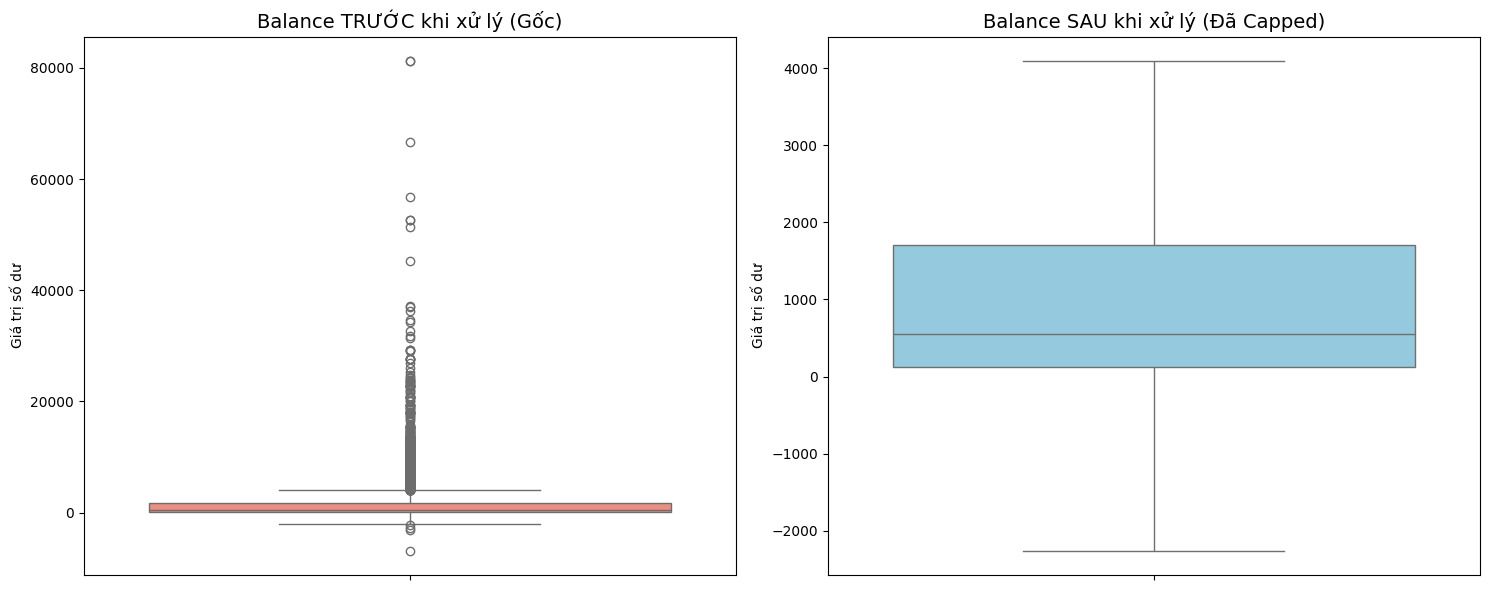

In [33]:
# Trực quan hóa: Boxplot Balance trước và sau xử lý ngoại lai
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df_raw, y='balance', ax=axes[0], color='salmon')
axes[0].set_title('Balance TRƯỚC khi xử lý (Gốc)', fontsize=14)
axes[0].set_ylabel('Giá trị số dư')

sns.boxplot(data=df_cleaned, y='balance', ax=axes[1], color='skyblue')
axes[1].set_title('Balance SAU khi xử lý (Đã Capped)', fontsize=14)
axes[1].set_ylabel('Giá trị số dư')

plt.tight_layout()
plt.show()

## **7. Ép Kiểu Dữ Liệu (Type Casting & Memory Optimization)**
Ép kiểu về đúng định dạng (float64, Int64, category) giúp tối ưu bộ nhớ và đảm bảo tính nhất quán cho các bước phân tích tiếp theo.

In [34]:
# Ép kiểu các cột số thực
float_cols = ['age', 'balance', 'duration']
for col in float_cols:
    df_cleaned[col] = df_cleaned[col].astype('float64')

# Ép kiểu các cột số nguyên (dùng Int64 để hỗ trợ NaN)
numeric_cols = ['day', 'campaign', 'pdays', 'previous']
for col in numeric_cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce').astype('Int64')

# Ép kiểu các cột phân loại sang category để tiết kiệm bộ nhớ
categorical_cols = ['job', 'marital', 'education', 'default', 'housing',
                    'loan', 'contact', 'month', 'poutcome']
for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].astype('category')

# Kiểm tra lại kiểu dữ liệu và dung lượng bộ nhớ
print(df_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        11162 non-null  float64 
 1   job        11162 non-null  category
 2   marital    11162 non-null  category
 3   education  11162 non-null  category
 4   default    11162 non-null  category
 5   balance    11162 non-null  float64 
 6   housing    11162 non-null  category
 7   loan       11162 non-null  category
 8   contact    11162 non-null  category
 9   day        11162 non-null  Int64   
 10  month      11162 non-null  category
 11  duration   11162 non-null  float64 
 12  campaign   11162 non-null  Int64   
 13  pdays      11162 non-null  Int64   
 14  previous   11162 non-null  Int64   
 15  poutcome   11162 non-null  category
 16  deposit    11162 non-null  int64   
dtypes: Int64(4), category(9), float64(3), int64(1)
memory usage: 841.2 KB
None


## **8. Xác Thực Sau Làm Sạch (Rule-Based Validation)**
Kiểm tra lại toàn bộ bộ dữ liệu theo các quy tắc nghiệp vụ để đảm bảo chất lượng trước khi xuất.

In [35]:
# Tập hợp các giá trị hợp lệ cho poutcome sau transformation
valid_poutcome = {"Success", "Failure", "Other", "New_customer"}

# Chạy kiểm tra toàn bộ quy tắc
validation_results = {
    "age_valid_range": df_cleaned["age"].between(18, 100).all(),
    "balance_min_check": (df_cleaned["balance"] >= -10000).all(),
    "duration_positive": (df_cleaned["duration"] > 0).all(),
    "campaign_valid_range": df_cleaned["campaign"].between(1, 100).all(),
    "poutcome_valid_values": df_cleaned["poutcome"].astype(str).isin(valid_poutcome).all()
}

import pprint
pprint.pprint(validation_results)

{'age_valid_range': np.True_,
 'balance_min_check': np.True_,
 'campaign_valid_range': np.True_,
 'duration_positive': np.True_,
 'poutcome_valid_values': np.True_}


## **9. So Sánh Trước/Sau & Xuất Kết Quả**
Hiển thị dữ liệu gốc và dữ liệu đã làm sạch để đối chiếu, sau đó xuất ra file CSV.

In [36]:
print("Raw data:")
display(df_raw)
print("Cleaned data:")
display(df_cleaned)

Raw data:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


Cleaned data:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59.0,Admin,Married,Secondary,No,2343.0,Yes,No,Cellular,5,May,1033.0,1,-1,0,New_customer,1
1,56.0,Admin,Married,Secondary,No,45.0,No,No,Cellular,5,May,1033.0,1,-1,0,New_customer,1
2,41.0,Technician,Married,Secondary,No,1270.0,Yes,No,Cellular,5,May,1033.0,1,-1,0,New_customer,1
3,55.0,Services,Married,Secondary,No,2476.0,Yes,No,Cellular,5,May,579.0,1,-1,0,New_customer,1
4,54.0,Admin,Married,Tertiary,No,184.0,No,No,Cellular,5,May,673.0,2,-1,0,New_customer,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33.0,Blue-Collar,Single,Primary,No,1.0,Yes,No,Cellular,20,Apr,257.0,1,-1,0,New_customer,0
11158,39.0,Services,Married,Secondary,No,733.0,No,No,Cellular,16,Jun,83.0,4,-1,0,New_customer,0
11159,32.0,Technician,Single,Secondary,No,29.0,No,No,Cellular,19,Aug,156.0,2,-1,0,New_customer,0
11160,43.0,Technician,Married,Secondary,No,0.0,No,Yes,Cellular,8,May,9.0,2,172,5,Failure,0


In [37]:
# Xuất dữ liệu đã làm sạch ra file mới
df_cleaned.to_csv('bank_data_cleaned.csv', index=False)
print("Đã xuất file bank_data_cleaned.csv thành công!")

Đã xuất file bank_data_cleaned.csv thành công!


## **10. Hàm Làm Sạch Tái Sử Dụng (Reusable Cleaning Pipeline)**
Đóng gói toàn bộ quy trình vào một hàm duy nhất để có thể áp dụng lại cho các file dữ liệu khác hoặc tích hợp vào pipeline tự động.

In [38]:
import pandas as pd
import numpy as np

def handle_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

def clean_bank_dataset(df_input: pd.DataFrame) -> pd.DataFrame:
    df = df_input.copy()

    # --- BƯỚC 1: Chuẩn hóa giá trị thiếu & Logic nghiệp vụ ---
    # (Giữ nguyên ý tưởng của bạn nhưng làm chuẩn hơn)
    df = df.replace(["none", "None", "N/A", "unknown", ""], np.nan)

    # Logic quan trọng: Chỉ pdays == -1 mới chắc chắn là New Customer
    if 'poutcome' in df.columns and 'pdays' in df.columns:
        df.loc[(df['poutcome'].isna()) & (df['pdays'] == -1), 'poutcome'] = 'New Customer'

    # --- BƯỚC 2: Xử lý cột văn bản & Ép kiểu Category ---
    categorical_cols = ['job', 'marital', 'education', 'default', 'housing',
                        'loan', 'contact', 'month', 'poutcome', 'deposit']

    for col in categorical_cols:
        if col in df.columns:
            # Chuyển Target 'deposit' về số 0/1 trước khi Title() để tránh lỗi
            if col == 'deposit':
                df[col] = df[col].astype(str).str.lower().map({'yes': 1, 'no': 0})
            else:
                df[col] = df[col].astype(str).str.strip().str.title()
                df[col] = df[col].replace('Nan', 'Unknown')

            df[col] = df[col].astype('category')

    # --- BƯỚC 3: Xử lý ngoại lai (Outliers) - ĐÂY LÀ PHẦN BẠN ĐANG THIẾU ---
    # Phải gọt dũa dữ liệu số trước khi ép kiểu cuối cùng
    cols_to_fix = ['balance', 'duration', 'campaign']
    for col in cols_to_fix:
        if col in df.columns:
            df = handle_outliers_iqr(df, col)

    # --- BƯỚC 4: Ép kiểu số chuẩn ---
    float_cols = ['age', 'balance', 'duration']
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('float64')

    numeric_cols = ['day', 'campaign', 'pdays', 'previous']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

    return df
# Ví dụ sử dụng
df_raw = pd.read_csv('bank_data.csv')
df_cleaned.to_csv('bank_data_cleaned.csv', index=False)

In [39]:
# Xuất dữ liệu đã làm sạch ra file mới
df_cleaned.to_csv('bank_data_cleaned.csv', index=False)

print("Đã xuất file bank_data_cleaned.csv thành công!")

Đã xuất file bank_data_cleaned.csv thành công!
